In [3]:
import pandas as pd
df = pd.read_csv(r"C:\bank_churn_analysis/Churn_modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [27]:
df.shape

(10000, 14)

In [29]:
print("duplicate rows:",df.duplicated().sum())

duplicate rows: 0


In [37]:
df = df.drop(columns= ["RowNumber","CustomerId","Surname"])
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [39]:
import numpy as np

# 1. Age group buckets
bins = [18, 30, 45, 60, 100]
labels = ["18-30", "31-45", "46-60", "60+"]
df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels, right=True)

# 2. Balance-to-salary ratio
df["BalanceToSalaryRatio"] = df["Balance"] / df["EstimatedSalary"].replace(0, np.nan)

# 3. High-value customer flag
median_balance = df["Balance"].median()
df["IsHighValue"] = ((df["Balance"] > median_balance) & (df["NumOfProducts"] >= 2)).astype(int)

df[["AgeGroup", "BalanceToSalaryRatio", "IsHighValue"]].head()

,AgeGroup,BalanceToSalaryRatio,IsHighValue
0,31-45,0.000000,0
1,31-45,0.744677,0
2,31-45,1.401375,1
3,31-45,0.000000,0
4,31-45,1.587055,0


In [41]:
churn_rate = df["Exited"].mean()
print(f"Overall churn rate: {churn_rate:.1%}")

Overall churn rate: 20.4%


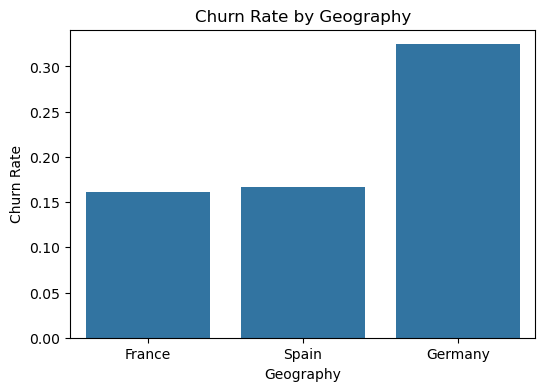

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(data=df, x="Geography", y="Exited", estimator=np.mean, errorbar=None)
plt.title("Churn Rate by Geography")
plt.ylabel("Churn Rate")
plt.show()

In [45]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [47]:
df.groupby("Geography")[["Balance", "NumOfProducts", "IsActiveMember", "Age"]].mean()

,Balance,NumOfProducts,IsActiveMember,Age
Geography,,,,
France,62092.636516,1.530913,0.516753,38.511767
Germany,119730.116134,1.519729,0.497409,39.771622
Spain,61818.147763,1.539362,0.529673,38.890997


In [49]:
df.groupby("Exited")["Balance"].mean()

Exited
0    72745.296779
1    91108.539337
Name: Balance, dtype: float64

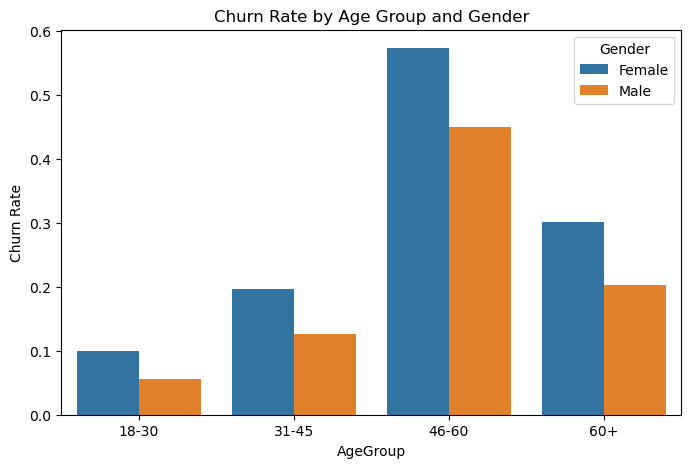

In [51]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="AgeGroup", y="Exited", hue="Gender", estimator=np.mean, errorbar=None)
plt.title("Churn Rate by Age Group and Gender")
plt.ylabel("Churn Rate")
plt.show()

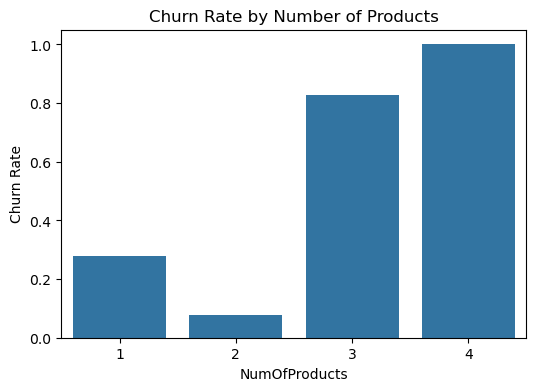

In [53]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="NumOfProducts", y="Exited", estimator=np.mean, errorbar=None)
plt.title("Churn Rate by Number of Products")
plt.ylabel("Churn Rate")
plt.show()

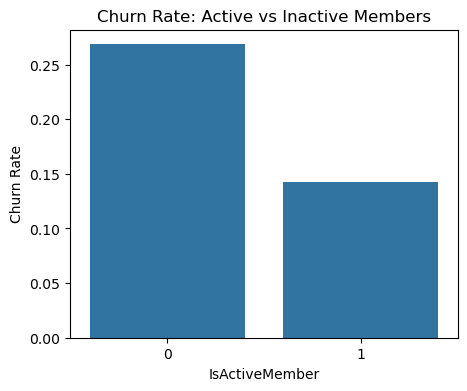

In [55]:
plt.figure(figsize=(5,4))
sns.barplot(data=df, x="IsActiveMember", y="Exited", estimator=np.mean, errorbar=None)
plt.title("Churn Rate: Active vs Inactive Members")
plt.ylabel("Churn Rate")
plt.show()

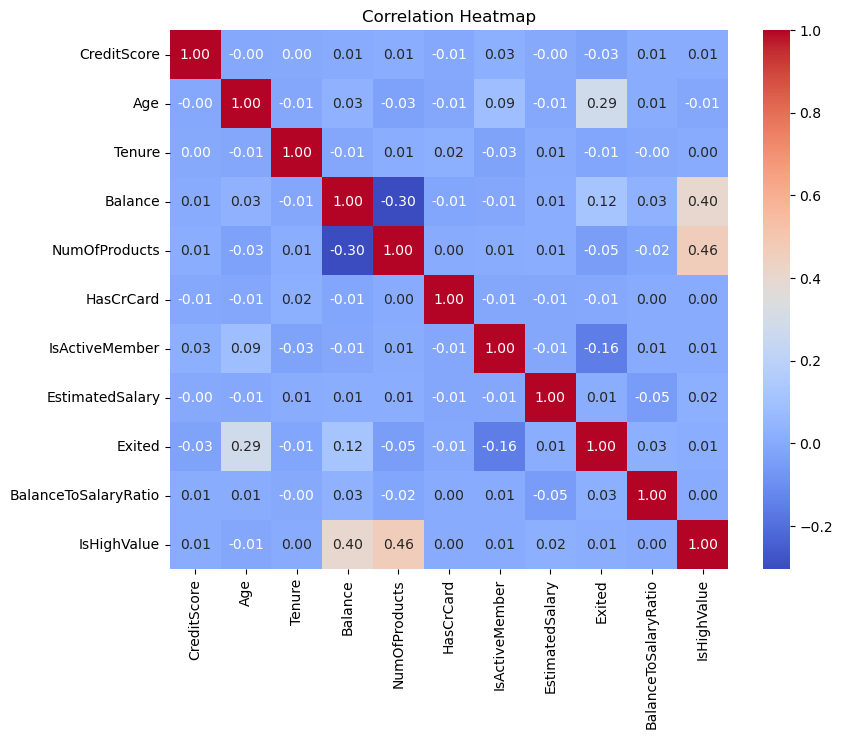

In [57]:
numeric_cols = df.select_dtypes(include=[np.number])
plt.figure(figsize=(9,7))
sns.heatmap(numeric_cols.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Executive Summary

- Overall churn rate: 20.4%
- Germany churns at nearly double the rate of France/Spain, despite having fewer customers — driven by higher average balances in that segment
- The 46-60 age group has the highest churn risk, and within that group, churn is notably higher among women
- Customers with 3-4 products churn dramatically more than those with 1-2 — a non-linear pattern invisible in correlation analysis
- Inactive members churn at ~2x the rate of active members — the most actionable lever for retention

## Recommendations

1. **Age (46-60):** This segment is likely in an active wealth-management or pre-retirement phase, making them more likely to compare options and switch banks. The bank should offer this age group tailored retirement planning products, dedicated relationship managers, and loyalty incentives to reduce their motivation to leave. Interestingly, churn is higher among women within this bracket — this warrants further investigation (e.g., differences in product fit, financial advisory access, or communication style) before shaping any targeted intervention, to ensure any response is need-based rather than demographic-based.

2. **Number of Products (3-4 products):** High-product customers have the most to gain by switching if rates or terms aren't competitive. The bank should audit interest rates, fees, and account terms for this segment, and regularly revise product bundles and pricing to stay competitive with rivals.

3. **Inactive Members:** Inactivity nearly doubles churn risk, suggesting low engagement leads to disengagement from the bank entirely. A targeted re-engagement campaign — fee waivers, personalized offers, or simplified account features — could re-engage this segment before they leave.

## MACHINE LEARNING: RANDOM FOREST CHURN PREDICTION MODEL

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*70)
print("RANDOM FOREST CHURN PREDICTION MODEL")
print("="*70)


RANDOM FOREST CHURN PREDICTION MODEL


# Get features (drop non-numeric columns manually)

In [42]:
cols_to_drop = ['Exited', 'RowNumber', 'CustomerId', 'Surname', 'Geography', 'Gender']
X = df.drop(cols_to_drop, axis=1)
y = df['Exited']

print(f"\nDataset: {X.shape[0]} samples, {X.shape[1]} features")


Dataset: 10000 samples, 8 features


# Split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training: {len(X_train)}, Testing: {len(X_test)}")


Training: 8000, Testing: 2000


# Train 

In [46]:
print("\nTraining model...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("✓ Model trained!")


Training model...
✓ Model trained!


# Predict

In [ ]:
y_pred = model.predict(X_test)

# Metrics

In [53]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n" + "="*70)
print("RESULTS")
print("="*70)
print(f"Accuracy:  {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall:    {rec*100:.2f}%")
print(f"F1-Score:  {f1:.4f}")


RESULTS
Accuracy:  85.85%
Precision: 74.55%
Recall:    42.49%
F1-Score:  0.5413


# Top features

In [55]:
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 5 Features:")
print(feat_imp.head(5).to_string(index=False))

print("\n✓ ML MODEL COMPLETE!")


Top 5 Features:
        Feature  Importance
            Age    0.248300
EstimatedSalary    0.167262
    CreditScore    0.161797
        Balance    0.148759
  NumOfProducts    0.131229

✓ ML MODEL COMPLETE!
